In [9]:
# ============================================================
# Heart Disease Prediction - Optimization & Ensemble
# ============================================================
# Sprint 3 / Notebook 03
# Amac: Hiperparametre optimizasyonu + Ensemble yontemleri
# Hedef: %85+ accuracy
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# scikit-learn
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# XGBoost
from xgboost import XGBClassifier

# Ayarlar
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Kutuphaneler yuklendi")
print(f"  pandas: {pd.__version__}")

Kutuphaneler yuklendi
  pandas: 2.2.2


In [10]:
# ============================================================
# 1. ISLENMIS VERIYI YUKLE VE BOL
# ============================================================
# Sprint 2'de temizlenmis veriyi (302 satir) kullaniyoruz.
# ============================================================

# Temiz veriyi yukle
df = pd.read_csv('../data/processed/heart_cleaned.csv')
print(f"Veri yuklendi: {df.shape[0]} satir, {df.shape[1]} sutun")

# X ve y ayrimi
X = df.drop('target', axis=1)
y = df['target']

# Ayni split (random_state=42 ile ayni sonuc)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Scaler'i Sprint 2'den yukle
scaler = joblib.load('../models/trained/scaler.pkl')
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame'e cevir (kolon isimlerini koru)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"\nTrain: {X_train_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")
print("\nSprint 2 ile ayni split kullaniliyor (reproducibility)")

Veri yuklendi: 302 satir, 14 sutun

Train: (241, 13)
Test:  (61, 13)

Sprint 2 ile ayni split kullaniliyor (reproducibility)


In [11]:
# ============================================================
# 2. GRIDSEARCHCV - HIPERPARAMETRE OPTIMIZASYONU
# ============================================================
# Her model icin en iyi parametreleri ariyoruz.
# Yontem: 5-fold cross-validation, scoring='roc_auc'
# Sure: ~2-5 dakika
# ============================================================

import time

# Parametre gridleri
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'SVM': {
        'model': SVC(random_state=RANDOM_STATE, probability=True),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'max_features': ['sqrt', 'log2']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3]
        }
    }
}

# Sonuclari tutacak yer
optimized_results = []
best_models = {}

print("=" * 80)
print("HIPERPARAMETRE OPTIMIZASYONU BASLIYOR")
print("=" * 80)

total_start = time.time()

for name, config in param_grids.items():
    print(f"\n>> {name} optimize ediliyor...")
    start = time.time()
    
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    
    grid.fit(X_train_scaled, y_train)
    
    elapsed = time.time() - start
    
    # En iyi modeli al
    best_model = grid.best_estimator_
    best_models[name] = best_model
    
    # Test seti tahmini
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrikler
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)
    
    optimized_results.append({
        'Model': name,
        'Best CV Score (AUC)': grid.best_score_,
        'Test Accuracy': test_acc,
        'Test F1': test_f1,
        'Test ROC-AUC': test_auc,
        'Best Params': grid.best_params_
    })
    
    # Optimize edilmis modeli kaydet
    filename = name.lower().replace(' ', '_') + '_optimized.pkl'
    joblib.dump(best_model, f'../models/trained/{filename}')
    
    print(f"   En iyi CV AUC:    {grid.best_score_:.4f}")
    print(f"   Test Accuracy:    {test_acc:.4f}")
    print(f"   Test ROC-AUC:     {test_auc:.4f}")
    print(f"   En iyi parametreler: {grid.best_params_}")
    print(f"   Sure: {elapsed:.1f} saniye")

total_elapsed = time.time() - total_start
print(f"\n{'=' * 80}")
print(f"TOPLAM SURE: {total_elapsed:.1f} saniye ({total_elapsed/60:.1f} dakika)")
print(f"{'=' * 80}")

# Sonuclari DataFrame'e cevir
opt_df = pd.DataFrame(optimized_results)
opt_df_sorted = opt_df.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)

print("\nOPTIMIZE EDILMIS MODEL KARSILASTIRMASI")
print("=" * 80)
display_cols = ['Model', 'Best CV Score (AUC)', 'Test Accuracy', 'Test F1', 'Test ROC-AUC']
print(opt_df_sorted[display_cols].round(4).to_string(index=False))

# En iyi optimize edilmis model
best_name = opt_df_sorted.iloc[0]['Model']
best_auc = opt_df_sorted.iloc[0]['Test ROC-AUC']
print(f"\nEN IYI OPTIMIZE EDILMIS MODEL: {best_name} (ROC-AUC: {best_auc:.4f})")

# Tabloyu kaydet
opt_df_sorted.to_csv('../models/metrics/optimized_results.csv', index=False)
print(f"\nKaydedildi: models/metrics/optimized_results.csv")

HIPERPARAMETRE OPTIMIZASYONU BASLIYOR

>> Logistic Regression optimize ediliyor...
   En iyi CV AUC:    0.9111
   Test Accuracy:    0.8033
   Test ROC-AUC:     0.8810
   En iyi parametreler: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
   Sure: 4.2 saniye

>> KNN optimize ediliyor...
   En iyi CV AUC:    0.9081
   Test Accuracy:    0.8689
   Test ROC-AUC:     0.9058
   En iyi parametreler: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
   Sure: 0.2 saniye

>> SVM optimize ediliyor...
   En iyi CV AUC:    0.9058
   Test Accuracy:    0.8033
   Test ROC-AUC:     0.8810
   En iyi parametreler: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   Sure: 1.1 saniye

>> Decision Tree optimize ediliyor...
   En iyi CV AUC:    0.8398
   Test Accuracy:    0.7049
   Test ROC-AUC:     0.7971
   En iyi parametreler: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
   Sure: 0.2 saniye

>> Random Forest optimize ediliyor...
   En iyi CV AUC:    0.9167
   Test A

In [12]:
# Ensemble Yontemleri - Voting, Bagging, Stacking

print("=" * 60)
print("ENSEMBLE YONTEMLERI EGITIMI")
print("=" * 60)

# En iyi 3 modeli al (optimize edilmis)
top3 = opt_df_sorted.head(3)['Model'].tolist()
print(f"\nEnsemble icin secilen modeller: {top3}")

# Bu modelleri estimator listesine al
estimators = [(name, best_models[name]) for name in top3]

ensemble_results = []

# 1. VOTING CLASSIFIER (Soft)
print("\n>> Voting Classifier (soft) egitiliyor...")
voting = VotingClassifier(estimators=estimators, voting='soft')
voting.fit(X_train_scaled, y_train)
y_pred = voting.predict(X_test_scaled)
y_proba = voting.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"   Test Accuracy: {acc:.4f}")
print(f"   Test ROC-AUC:  {auc:.4f}")
ensemble_results.append({'Model': 'Voting (Soft)', 'Test Accuracy': acc, 'Test F1': f1, 'Test ROC-AUC': auc})
joblib.dump(voting, '../models/trained/ensemble_voting.pkl')

# 2. BAGGING CLASSIFIER
print("\n>> Bagging Classifier egitiliyor...")
best_single = best_models[opt_df_sorted.iloc[0]['Model']]
bagging = BaggingClassifier(estimator=best_single, n_estimators=10, random_state=42, n_jobs=-1)
bagging.fit(X_train_scaled, y_train)
y_pred = bagging.predict(X_test_scaled)
y_proba = bagging.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"   Test Accuracy: {acc:.4f}")
print(f"   Test ROC-AUC:  {auc:.4f}")
ensemble_results.append({'Model': 'Bagging', 'Test Accuracy': acc, 'Test F1': f1, 'Test ROC-AUC': auc})
joblib.dump(bagging, '../models/trained/ensemble_bagging.pkl')

# 3. STACKING CLASSIFIER
print("\n>> Stacking Classifier egitiliyor...")
final_estimator = LogisticRegression(random_state=42, max_iter=1000)
stacking = StackingClassifier(estimators=estimators, final_estimator=final_estimator, cv=5, n_jobs=-1)
stacking.fit(X_train_scaled, y_train)
y_pred = stacking.predict(X_test_scaled)
y_proba = stacking.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"   Test Accuracy: {acc:.4f}")
print(f"   Test ROC-AUC:  {auc:.4f}")
ensemble_results.append({'Model': 'Stacking', 'Test Accuracy': acc, 'Test F1': f1, 'Test ROC-AUC': auc})
joblib.dump(stacking, '../models/trained/ensemble_stacking.pkl')

# Karsilastirma
ens_df = pd.DataFrame(ensemble_results)
ens_df_sorted = ens_df.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("ENSEMBLE SONUCLARI")
print("=" * 60)
print(ens_df_sorted.round(4).to_string(index=False))

best_ensemble = ens_df_sorted.iloc[0]['Model']
best_ens_auc = ens_df_sorted.iloc[0]['Test ROC-AUC']
print(f"\nEN IYI ENSEMBLE: {best_ensemble} - AUC: {best_ens_auc:.4f}")

ens_df_sorted.to_csv('../models/metrics/ensemble_results.csv', index=False)
print("Kaydedildi: models/metrics/ensemble_results.csv")

ENSEMBLE YONTEMLERI EGITIMI

Ensemble icin secilen modeller: ['KNN', 'Logistic Regression', 'SVM']

>> Voting Classifier (soft) egitiliyor...
   Test Accuracy: 0.8197
   Test ROC-AUC:  0.9037

>> Bagging Classifier egitiliyor...
   Test Accuracy: 0.8361
   Test ROC-AUC:  0.8999

>> Stacking Classifier egitiliyor...
   Test Accuracy: 0.8361
   Test ROC-AUC:  0.9026

ENSEMBLE SONUCLARI
        Model  Test Accuracy  Test F1  Test ROC-AUC
Voting (Soft)         0.8197   0.8406        0.9037
     Stacking         0.8361   0.8485        0.9026
      Bagging         0.8361   0.8529        0.8999

EN IYI ENSEMBLE: Voting (Soft) - AUC: 0.9037
Kaydedildi: models/metrics/ensemble_results.csv


In [13]:
# Final Model Belirleme ve Kaydetme

# Tum sonuclari birlestir
print("TUM MODELLERIN FINAL KARSILASTIRMASI")
print("=" * 70)

# Optimize edilmis modeller
optimized_summary = opt_df_sorted[['Model', 'Test Accuracy', 'Test F1', 'Test ROC-AUC']].copy()
optimized_summary['Tip'] = 'Optimize'

# Ensemble modeller
ensemble_summary = ens_df_sorted[['Model', 'Test Accuracy', 'Test F1', 'Test ROC-AUC']].copy()
ensemble_summary['Tip'] = 'Ensemble'

# Birlestir
all_models = pd.concat([optimized_summary, ensemble_summary], ignore_index=True)
all_models_sorted = all_models.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)

print(all_models_sorted.round(4).to_string(index=False))

# En iyi modeli bul
best_overall = all_models_sorted.iloc[0]
best_model_name = best_overall['Model']
best_auc_score = best_overall['Test ROC-AUC']
best_acc_score = best_overall['Test Accuracy']

print(f"\nFINAL MODEL: {best_model_name}")
print(f"  Test Accuracy: {best_acc_score:.4f}")
print(f"  Test ROC-AUC:  {best_auc_score:.4f}")

# Final modeli yukle
if best_overall['Tip'] == 'Optimize':
    filename = best_model_name.lower().replace(' ', '_') + '_optimized.pkl'
else:
    if best_model_name == 'Voting (Soft)':
        filename = 'ensemble_voting.pkl'
    elif best_model_name == 'Bagging':
        filename = 'ensemble_bagging.pkl'
    else:
        filename = 'ensemble_stacking.pkl'

best_model = joblib.load(f'../models/trained/{filename}')

# best_model.pkl olarak kopyala (Flask bunu kullanacak)
joblib.dump(best_model, '../models/trained/best_model.pkl')
print(f"\nFinal model kaydedildi: models/trained/best_model.pkl")
print(f"Kaynak dosya: {filename}")

# Final metrikleri JSON olarak kaydet
import json
final_metrics = {
    'model_name': best_model_name,
    'model_type': str(type(best_model).__name__),
    'test_accuracy': float(best_acc_score),
    'test_roc_auc': float(best_auc_score),
    'test_f1': float(best_overall['Test F1']),
    'training_samples': int(X_train_scaled.shape[0]),
    'test_samples': int(X_test_scaled.shape[0]),
    'features': list(X.columns),
    'sprint': 'Sprint 3 - Final'
}

os.makedirs('../models/metrics', exist_ok=True)
with open('../models/metrics/final_model_info.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)

print("Metrikler kaydedildi: models/metrics/final_model_info.json")
print("\nTAM KARSILASTIRMA TABLOSU:")
all_models_sorted.to_csv('../models/metrics/all_models_comparison.csv', index=False)
print("Kaydedildi: models/metrics/all_models_comparison.csv")

TUM MODELLERIN FINAL KARSILASTIRMASI
              Model  Test Accuracy  Test F1  Test ROC-AUC      Tip
                KNN         0.8689   0.8824        0.9058 Optimize
      Voting (Soft)         0.8197   0.8406        0.9037 Ensemble
           Stacking         0.8361   0.8485        0.9026 Ensemble
            Bagging         0.8361   0.8529        0.8999 Ensemble
Logistic Regression         0.8033   0.8235        0.8810 Optimize
                SVM         0.8033   0.8286        0.8810 Optimize
      Random Forest         0.7705   0.7879        0.8582 Optimize
            XGBoost         0.7377   0.7576        0.8355 Optimize
      Decision Tree         0.7049   0.7273        0.7971 Optimize

FINAL MODEL: KNN
  Test Accuracy: 0.8689
  Test ROC-AUC:  0.9058

Final model kaydedildi: models/trained/best_model.pkl
Kaynak dosya: knn_optimized.pkl
Metrikler kaydedildi: models/metrics/final_model_info.json

TAM KARSILASTIRMA TABLOSU:
Kaydedildi: models/metrics/all_models_comparison.csv


BASELINE vs OPTIMIZED KARSILASTIRMASI
              Model  Baseline AUC  Optimized AUC  Iyilesme
Logistic Regression        0.8712         0.8810    1.1180
      Random Forest        0.8588         0.8582   -0.0630
                SVM        0.8420         0.8810    4.6272
                KNN        0.8377         0.9058    8.1395
            XGBoost        0.8323         0.8355    0.3901
      Decision Tree        0.8317         0.7971   -4.1640

Grafik kaydedildi: reports/figures/11_sprint3_final.png


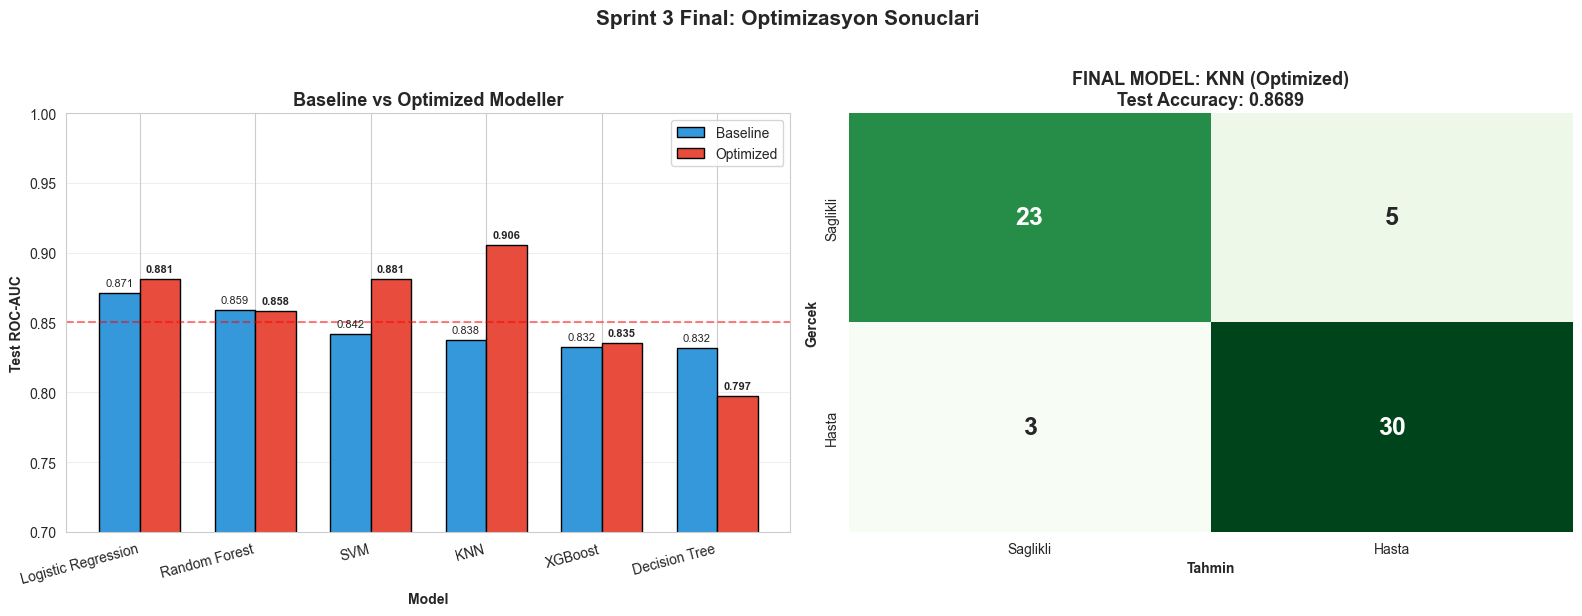


FINAL MODEL - SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

    Saglikli       0.88      0.82      0.85        28
       Hasta       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [14]:
# Sprint 2 vs Sprint 3 Karsilastirma + Final Confusion Matrix

# 1. KARSILASTIRMA GRAFIGI: Baseline vs Optimized
# Sprint 2 baseline sonuclarini yukle
baseline_df = pd.read_csv('../models/metrics/baseline_results.csv')
optimized_df = pd.read_csv('../models/metrics/optimized_results.csv')

# Ortak modeller icin karsilastirma
comparison = pd.DataFrame({
    'Model': baseline_df['Model'],
    'Baseline AUC': baseline_df['Test ROC-AUC'].values,
    'Optimized AUC': optimized_df.set_index('Model').loc[baseline_df['Model']]['Test ROC-AUC'].values
})

# Iyilesme yuzdesi
comparison['Iyilesme'] = ((comparison['Optimized AUC'] - comparison['Baseline AUC']) / comparison['Baseline AUC'] * 100)

print("BASELINE vs OPTIMIZED KARSILASTIRMASI")
print("=" * 60)
print(comparison.round(4).to_string(index=False))

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Baseline vs Optimized
x = np.arange(len(comparison))
width = 0.35

axes[0].bar(x - width/2, comparison['Baseline AUC'], width, label='Baseline', color='#3498db', edgecolor='black')
axes[0].bar(x + width/2, comparison['Optimized AUC'], width, label='Optimized', color='#e74c3c', edgecolor='black')

axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Test ROC-AUC', fontweight='bold')
axes[0].set_title('Baseline vs Optimized Modeller', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Hedef')
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Bar etiketi
for i, (b, o) in enumerate(zip(comparison['Baseline AUC'], comparison['Optimized AUC'])):
    axes[0].text(i - width/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, o + 0.005, f'{o:.3f}', ha='center', fontsize=8, fontweight='bold')

# Sag: Final modelin confusion matrix
final_model = joblib.load('../models/trained/best_model.pkl')
y_pred_final = final_model.predict(X_test_scaled)
cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Saglikli', 'Hasta'],
            yticklabels=['Saglikli', 'Hasta'],
            ax=axes[1], cbar=False,
            annot_kws={'size': 18, 'fontweight': 'bold'})

acc = accuracy_score(y_test, y_pred_final)
axes[1].set_title(f'FINAL MODEL: KNN (Optimized)\nTest Accuracy: {acc:.4f}', 
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Tahmin', fontweight='bold')
axes[1].set_ylabel('Gercek', fontweight='bold')

plt.suptitle('Sprint 3 Final: Optimizasyon Sonuclari',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/11_sprint3_final.png', dpi=150, bbox_inches='tight')
print("\nGrafik kaydedildi: reports/figures/11_sprint3_final.png")
plt.show()

# Final classification report
print("\n" + "=" * 60)
print("FINAL MODEL - SINIFLANDIRMA RAPORU")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Saglikli', 'Hasta']))